In [1]:
from langchain_openai import ChatOpenAI

model = ChatOpenAI(model='gpt-4o-mini', temperature=0.01)

In [2]:
from typing import Annotated
from typing_extensions import TypedDict


from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

class State(TypedDict):
    """
    State 클래스는 TypedDict를 상속받습니다.

    속성: 
        messages (Annotated[list[str], add_messages]) : 메시지들은 "list" 타입을 가집니다.
        주석에 있는 'add_messages' 함수는 이 상태 키가 어떻게 업데이트되어야 하는지를 정의합니다.
        (이 경우, 메시지를 덮어쓰는 대신 리스트에 추가합니다)
    """
    messages: Annotated[list[str], add_messages]

graph_builder = StateGraph(State)

In [3]:
# %pip install langchain_community


In [4]:
# %pip install bs4

In [5]:
from langchain_core.tools import tool
from datetime import datetime
import pytz
from langchain_community.tools import DuckDuckGoSearchResults
from langchain_community.utilities import DuckDuckGoSearchAPIWrapper

import bs4
from langchain_community.document_loaders import WebBaseLoader



@tool
def get_current_time(timezone:str, location:str) -> str:
    """현재 시각을 반환하는 함수."""
    try:
        tz = pytz.timezone(timezone)
        now = datetime.now(tz).strftime('%Y-%m-%d %H:%M:%S')
        result = f'{timezone} ({location}) 현재 시각 {now}'
        return result
    except pytz.UnknownTimeZoneError:
        return f'알 수 없는 타임존: {timezone}'
    
@tool
def get_web_search(query: str, search_period: str='m') -> str:
    """
    웹 검색을 수행하는 함수.
    
    Args:
        query (str): 검색어
        search_period (str): 검색 기간 (e.g., 'w' for past week (default), 'm' for past month, 'y' for past year, 'd' for past day)

    Returns:
        str: 검색 결과
    """

    wrapper = DuckDuckGoSearchAPIWrapper(
        time=search_period
    )

    print('\n------- WEB SEARCH -------')
    print(query)
    print(search_period)

    search = DuckDuckGoSearchResults(
        api_wrapper=wrapper,
        results_separator=';\n'
    )

    searched = search.invoke(query)

    for i, result in enumerate(searched.split(';\n')):
        print(f'{i+1}. {result}')

    return searched

tools = [get_current_time, get_web_search]

USER_AGENT environment variable not set, consider setting it to identify your requests.


In [6]:
tools[0].invoke({"timezone":"Asia/Seoul", "location":"서울"})

'Asia/Seoul (서울) 현재 시각 2026-05-14 16:06:51'

In [7]:
%pip install -U ddgs

Note: you may need to restart the kernel to use updated packages.


In [8]:
tools[1].invoke({"query":"파이썬", "search_period": "m"})


------- WEB SEARCH -------
파이썬
m
1. snippet: 3 weeks ago - )은 1991년 네덜란드계 소프트웨어 엔지니어인 귀도 반 로섬이 발표한 고급 프로그래밍 언어로, '인터프리터를 사용하는 객체지향 언어'이자 플랫폼에 독립적인, 동적 타이핑(dynamically typed) 대화형 언어다., title: 파이썬 - 위키백과, 우리 모두의 백과사전, link: https://ko.wikipedia.org/wiki/파이썬
2. snippet: 18 hours ago - Python is a high-level, general-purpose programming language that emphasizes code readability, simplicity, and ease-of-writing with the use of significant indentation, "plain English" naming, an extensive ("batteries-included") standard library, and garbage collection., title: Python (programming language) - Wikipedia, link: https://en.wikipedia.org/wiki/Python_(programming_language)
3. snippet: 3 weeks ago - 즉, 같은 것을 하는 다른 방법이 있는지 여부 자체가 중요한 것이 아닌, 가장 명백한 방법이 존재한다면 파이썬의 정신에 위배되지 않는다는 것이다.[5] 파이썬의 디자인 철학에 맞는 코드를 짜는 것을 파이써닉(pythonic)이라고 부른다., title: Python - 파이썬, link: https://namu.wiki/w/Python
4. snippet: 3 weeks ago - 2026년 Windows, macOS, Linux에 파이썬 설치하는 법 — 다운로드 링크, 버전 확인, PATH 설정, 자주 나오는 설치 에러 해결법까지., 

'snippet: 3 weeks ago - )은 1991년 네덜란드계 소프트웨어 엔지니어인 귀도 반 로섬이 발표한 고급 프로그래밍 언어로, \'인터프리터를 사용하는 객체지향 언어\'이자 플랫폼에 독립적인, 동적 타이핑(dynamically typed) 대화형 언어다., title: 파이썬 - 위키백과, 우리 모두의 백과사전, link: https://ko.wikipedia.org/wiki/파이썬;\nsnippet: 18 hours ago - Python is a high-level, general-purpose programming language that emphasizes code readability, simplicity, and ease-of-writing with the use of significant indentation, "plain English" naming, an extensive ("batteries-included") standard library, and garbage collection., title: Python (programming language) - Wikipedia, link: https://en.wikipedia.org/wiki/Python_(programming_language);\nsnippet: 3 weeks ago - 즉, 같은 것을 하는 다른 방법이 있는지 여부 자체가 중요한 것이 아닌, 가장 명백한 방법이 존재한다면 파이썬의 정신에 위배되지 않는다는 것이다.[5] 파이썬의 디자인 철학에 맞는 코드를 짜는 것을 파이써닉(pythonic)이라고 부른다., title: Python - 파이썬, link: https://namu.wiki/w/Python;\nsnippet: 3 weeks ago - 2026년 Windows, macOS, Linux에 파이썬 설치하는 법 — 다운로드 링크, 버전 확인, PATH 설정, 자주 나오는 설치 에러 해결법까지., title: 파이썬 설치 방법: Windows, macOS, Lin

In [9]:
for tool in tools:
    print(tool.name, tool)

get_current_time name='get_current_time' description='현재 시각을 반환하는 함수.' args_schema=<class 'langchain_core.utils.pydantic.get_current_time'> func=<function get_current_time at 0x0000017E09CA99E0>
get_web_search name='get_web_search' description="웹 검색을 수행하는 함수.\n\nArgs:\n    query (str): 검색어\n    search_period (str): 검색 기간 (e.g., 'w' for past week (default), 'm' for past month, 'y' for past year, 'd' for past day)\n\nReturns:\n    str: 검색 결과" args_schema=<class 'langchain_core.utils.pydantic.get_web_search'> func=<function get_web_search at 0x0000017E0D708720>


In [10]:
model_with_tools = model.bind_tools(tools)

def generate(state:State):
    """
    주어진 상태를 기반으로 챗봇의 응답 메시지를 생성합니다.

    매개변수:
    state (State): 현재 대화 상태를 나타내는 객체로, 이전 메시지들이 포함되어 있습니다.

    반환값:
    dict: 모델이 생성한 응답 메시지를 포함하는 딕셔너리
        형식은 {'messages': [응답 메시지]}입니다.
    """
    return {"messages": model_with_tools.invoke(state["messages"])}

graph_builder.add_node("generate", generate)

In [11]:
import json
from langchain_core.messages import ToolMessage



class BasicToolNode:
    """
    도구를 실행하는 노드 클래스입니다. 마지막 AIMessage에서 요청된 도구를 실행합니다.
    Attributes:
        tools_by_name (dict): 도구 이름을 키로 하고 도구 객체를 값으로 가지는 사전입니다.
    Methods:
        __init__(tools: list): 도구 객체들의 리스트를 받아서 초기화합니다.
        __call__(inputs: dict): 입력 메시지를 받아서 도구를 실행하고 결과 메시지를 반환합니다.
    """
    """A node that runs the tools requested in the last AIMessages."""

    def __init__(self, tools: list) -> None:
        self.tools_by_name = {tool.name: tool for tool in tools}

    def __call__(self, inputs: dict):
        if messages := inputs.get("messages", []):
            message = messages[-1]
        else:
            raise ValueError("No message found in input")
        outputs = []
        for tool_call in message.tool_calls:
            tool_result = self.tools_by_name[tool_call["name"]].invoke(tool_call["args"])
            outputs.append(
                ToolMessage(
                    content=json.dumps(tool_result),
                    name=tool_call["name"],
                    tool_call_id=tool_call["id"],
                )
            )
        return {"messages": messages + outputs}
    
tool_node = BasicToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

In [13]:
def route_tools(state: State):
    """
    마지막 메시지에 도구 호출이 있는 경우 ToolNode로 라우팅하고,
    그렇지 않은 경우 끝으로 라우팅하기 위해 conditional_edge에서 사용합니다.
    """
    if isinstance(state, list):
        ai_message = state[-1]
    elif messages := state.get("messages", []):
        ai_message = messages[-1]
    else:
        raise ValueError(f"tool_edge 입력 상태에서 메시지를 찾을 수 없습니다: {state}")
    
    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return "tools"
    return END

graph_builder.add_edge(START, "generate")

graph_builder.add_conditional_edges(
    "generate",
    route_tools,
    {"tools": "tools", END:END}
)

graph_builder.add_edge('tools', 'generate')
graph = graph_builder.compile()

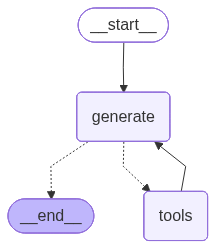

In [14]:
from IPython.display import Image, display


try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [15]:
from langchain_core.messages import AIMessageChunk, HumanMessage

inputs = [HumanMessage(content="지금 서울 몇 시야?")]

gathered = None

for msg, metadata in graph.stream({"messages": inputs}, stream_mode="messages"):
    if isinstance(msg, AIMessageChunk):
        print(msg.content, end='')

        if gathered is None:
            gathered = msg

        else:
            gathered = gathered + msg

gathered

현재 서울의 시각은 2026년 5월 14일 16시 16분입니다.

AIMessageChunk(content='현재 서울의 시각은 2026년 5월 14일 16시 16분입니다.', additional_kwargs={}, response_metadata={'model_provider': 'openai', 'finish_reason': 'tool_callsstop', 'model_name': 'gpt-4o-mini-2024-07-18gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_b985008419fp_b985008419', 'service_tier': 'defaultdefault'}, id='lc_run--019e2557-df96-7363-b314-45463298bc3e', tool_calls=[{'name': 'get_current_time', 'args': {'timezone': 'Asia/Seoul', 'location': '서울'}, 'id': 'call_gN7b3QkqKYtYbaeEkAcQl0Qz', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 370, 'output_tokens': 47, 'total_tokens': 417, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}, tool_call_chunks=[{'name': 'get_current_time', 'args': '{"timezone":"Asia/Seoul","location":"서울"}', 'id': 'call_gN7b3QkqKYtYbaeEkAcQl0Qz', 'index': 0, 'type': 'tool_call_chunk'}], chunk_position='last')

In [16]:
from langchain_core.messages import AIMessageChunk, SystemMessage



about = "서울 월드컵 경기장 잔디 문제"

inputs = [SystemMessage(content=f"""
너는 신문기자이다.
최근 {about}에 대해 비판하는 심층 분석 기사를 쓰려고 한다.

- 최근 어떤 이슈가 있는지 검색하고, 사람들이 제일 관심있어 할만한 주제를 선정하고, 왜 선정했는지 말해줘.

- 그 내용으로 어떤 이슈가 있는지 검색하고, 사람들이 제일 관심있어 할만한 주제를 선정하고, 왜 선정했는지 말해줘.

- 그 내용으로 원고를 작성하기 위한 목차를 만들고, 목차 내용을 채우기 위해 추가로 검색할 내용을 리스트로 정리해봐.

- 검색할 리스트를 토대로 재검색해.

- 목차에 있는 내용을 작성하기 위해 더 검색이 필요한 정보가 있는지 확인하고, 있다면 추가로 검색해.

- 검색된 결과에 원하는 정보를 찾지 못했다면 다른 검색어로 재검색해도 좋아.

더 이상 검색할 내용이 없다면, 조선일보 신문 기사 형식으로 최종 기사를 작성한다.
제목, 부제, 리드문, 본문의 구성으로 작성한다. 본문 내용은 심층 분석 기사에 맞게 구체적이고 깊이 있게 작성해야 한다.

""")]

for msg, metadata in graph.stream({"messages": inputs}, stream_mode="messages"):
    if isinstance(msg, AIMessageChunk):
        print(msg.content, end='')


------- WEB SEARCH -------
서울 월드컵 경기장 잔디 문제
m
1. snippet: Apr 17, 2026 · (서울=뉴스1) 신건웅 기자 = 서울 마포구 서울월드컵경기장. 국내 최대 축구 성지로 불리지만, 그라운드 잔디는 늘 '보이지 않는 전쟁'을 치르고 있다. 해마다 여름이면 폭염과 씨름하고, 겨울이면 한파에 시달리며, 수십 차례의 경기와 행사로 쉴 새 없이 짓밟힌다., title: "햇빛도, 바람도 만든다"…상암 잔디가 '3중고' 버티는 비법 - 뉴스1, link: https://www.news1.kr/local/moi/6139075
2. snippet: 3 days ago · 기반 조성 분과에서는 잔디 품질 개선 방안을 중점적으로 논의한다. 경기장 잔디 상태가 선수들의 경기력은 물론 팬들의 관람 경험에 직결되는 만큼, 전문 장비와 인력 확보, 관리 기준 강화 등 경기장 관리 체계를 전반적으로 정비하는 방안을 살펴본다., title: 문체부, 프로축구 성장위 전체 회의…심판 신뢰 회복 방안 논의 : 네이..., link: https://sports.news.nate.com/view/20260511n08908
3. snippet: 3 days ago · 회의는 지속 성장 중인 프로축구의 기반을 강화하기 위해 마련됐다. 프로축구는 최근 심판 판정 신뢰도 문제, 경기장 잔디 품질, 수익 모델 등 분야에서 구조적 한계를 노출하고 있다. 관중은 최근 10년 새 66% 증가, 매출은 2배 뛰는 등 성장세를 이어가고 있지만 고질적인 문제를 해결하지 않으면 장기 ..., title: 관중 많아진 K리그, 심판·잔디 문제 여전…문체부, 현장 의견 듣는다 -..., link: https://www.mt.co.kr/culture/2026/05/11/2026051109051933005
4. snippet: 3 days ago · 프로축구의 성장에 발맞춰 심판 판정의 신뢰도를 높이고 경기장 잔디 품질을 개선하는 등 K리그의 '내실'을 다지기 위한 정책 논의